In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reading the CSV File

In [6]:
df=pd.read_csv("insurance.csv")

In [7]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Exploratry Data Analysis

## Step 1: Univariate Analysis

In [8]:
# Univariate Analysis simply means looking at one column at a time.

In [9]:
df.shape # to take the idea of no. of rows and columns 

(1338, 7)

In [10]:
df.head() # overview of the csv file

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
df.info() # overview Column Non-Null Count  Dtype 

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [12]:
df.describe() # applies on the those columns whose data type is numeric and gives informations like mean, median etc..

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.isnull().sum() # count of null values of each column

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
df.columns # shows the list of column names

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

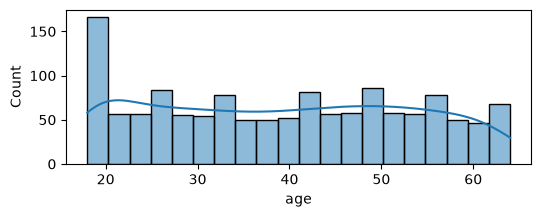

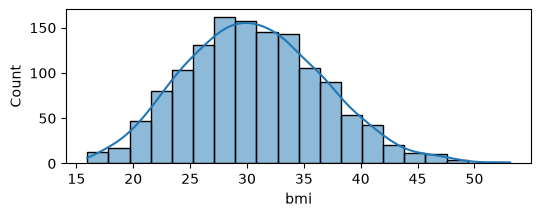

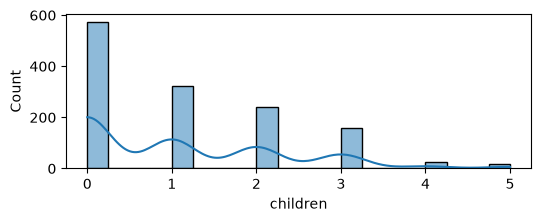

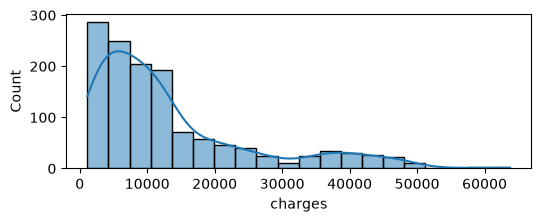

In [15]:
numeric_col=['age', 'bmi', 'children', 'charges']
for col in numeric_col:
    plt.figure(figsize=(6,2))
    sns.histplot(df[col],kde='True',bins=20)

<Axes: xlabel='smoker', ylabel='count'>

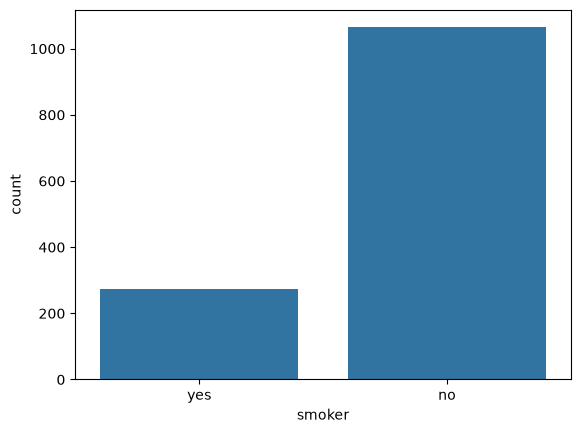

In [16]:
sns.countplot(x=df['smoker'])  # since smoker column is continous that is why used countplot

<Axes: xlabel='children', ylabel='count'>

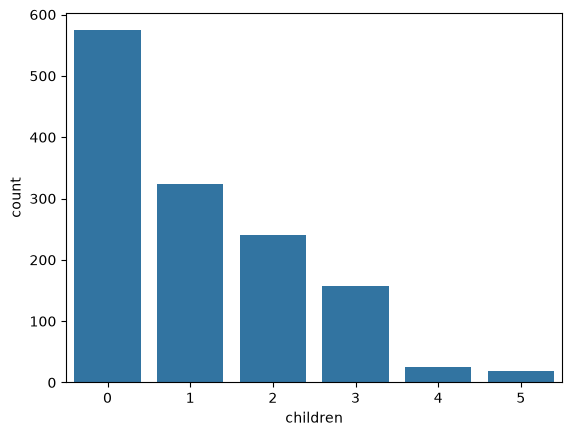

In [17]:
sns.countplot(x=df['children']) # since smoker column is continous

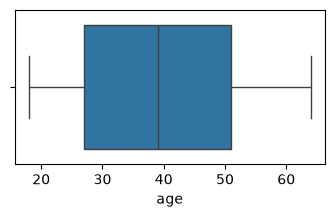

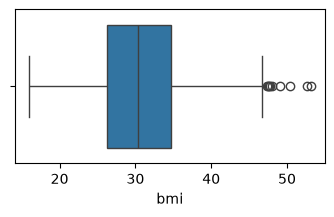

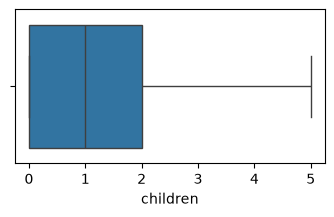

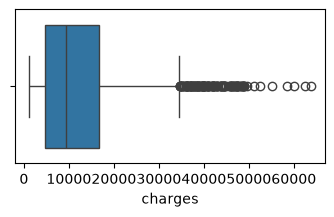

In [18]:
numeric_col=['age', 'bmi', 'children', 'charges']
for col in numeric_col:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])  # Box plots are used to visually summarize the distribution of numerical data and identify outliers

## Step 2: Bivariate Analysis

In [19]:
# Since we are likely trying to predict medical charges, we need to see how the other columns are affecting it 
#and how one column is corelated to another.

<Axes: >

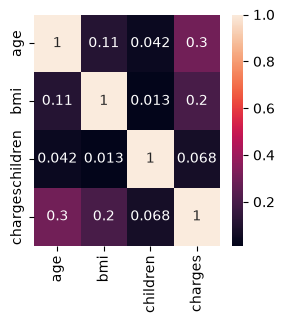

In [20]:
# Heatmaps : A heatmap shows the relationships and patterns between two different variables using color gradients.
# Can only be used for numeric data types only ..

plt.figure(figsize=(3,3))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and Preprocessing

In [21]:
df_clean=df.copy()  # creating a copy of the data and cleanong that dataframe

In [22]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df_clean.isnull().sum()# column-wise counting

df_clean.isnull().sum().sum() # whole sum in once

np.int64(0)

In [24]:
df_clean.drop_duplicates(inplace=True)

In [25]:
df.shape  # in original (1338, 7)
df_clean.shape # in copy (1337, 7)

(1337, 7)

## Converting the non-numeric D-type Columns to Numeric type

In [26]:
df_clean.dtypes 

# age           int64
# sex             str  # to be converted
# bmi         float64  
# children      int64
# smoker          str  # to be converted
# region          str  # to be converted
# charges     float64

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

### Label Encoding

In [27]:
df_clean['sex'].count() # O/P male + female 
df_clean['sex'].value_counts()  # O/P male count and female count 

sex
male      675
female    662
Name: count, dtype: int64

In [28]:
df_clean['sex'] = df_clean['sex'].astype(str).str.strip()
df_clean['sex'] = df_clean['sex'].map({"male": 0,"female": 1})

In [29]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [30]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [31]:
df_clean['smoker']=df_clean['smoker'].map({"yes":1,"no":0})

In [32]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


### One Hot Encoding

In [33]:
df['region'].value_counts() # for this one hot encoding will be used

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [34]:
df_clean=pd.get_dummies(df_clean,columns=['region'],drop_first=True)  # drop first means the existing column to be dropped

In [35]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [36]:
df_clean = df_clean.astype(int)

In [37]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature Engineering and Extraction

In [38]:
df_clean["bmi category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Healthy", "Overweight", "Obese"],
    right=False
)

In [39]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Healthy
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [40]:
df_clean=pd.get_dummies(df_clean,columns=["bmi category"],drop_first=True)

In [41]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Healthy,bmi category_Overweight,bmi category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [42]:
df_clean.replace({True: 1, False: 0}, inplace=True)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Healthy,bmi category_Overweight,bmi category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [43]:
df_clean=df_clean.astype(int)
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Healthy,bmi category_Overweight,bmi category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


# Feature Scaling

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
cols = ['age', 'bmi', 'children']

scaler = StandardScaler()
df_clean[cols] = scaler.fit_transform(df_clean[cols])

In [46]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Healthy,bmi category_Overweight,bmi category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


# Pearson Correlation

In [47]:
from scipy.stats import pearsonr

# Pearson Correlation helps in checking the list of features w.r.t the target

In [53]:
selected_features = [
    'age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_Healthy', 'bmi category_Overweight', 'bmi category_Obese'
]

correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,smoker,0.787234
0,age,0.298309
10,bmi category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,sex,-0.058046
8,bmi category_Healthy,-0.104042


# Chi-Square Test

In [57]:
cat_features = [
    'age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_Healthy', 'bmi category_Overweight', 'bmi category_Obese'
]

In [58]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
age,1509.13025,0.0,Reject Null (Keep Feature)
smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
sex,10.258784,0.01649,Reject Null (Keep Feature)
bmi,144.758888,0.017278,Reject Null (Keep Feature)
bmi category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi category_Healthy,3.708088,0.29476,Accept Null (Drop Feature)


## Downloading the Final prepared dataset for training

In [60]:
final_df = df_clean[['age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_Healthy', 'bmi category_Overweight', 'bmi category_Obese']]

In [61]:
final_df

,age,bmi,children,sex,smoker,region_northwest,region_southeast,region_southwest,bmi category_Healthy,bmi category_Overweight,bmi category_Obese
0,-1.440418,-0.517949,-0.909234,1,1,0,0,1,0,1,0
1,-1.511647,0.462463,-0.079442,0,0,0,1,0,0,0,1
2,-0.799350,0.462463,1.580143,0,0,0,1,0,0,0,1
3,-0.443201,-1.334960,-0.909234,0,0,1,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,1,0,0,0,0,1
1334,-1.511647,0.135659,-0.909234,1,0,0,0,0,0,0,1
1335,-1.511647,0.952670,-0.909234,1,0,0,1,0,0,0,1
1336,-1.297958,-0.844753,-0.909234,1,0,0,0,1,0,1,0


In [62]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
